In [34]:
import pickle

import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.io import read_image

In [35]:
nerv_save_dir = '../plotting_source_data/NeRV/B-representation_is_distributed'
mlp_save_dir = '../plotting_source_data/MLP/B-representation_is_distributed'

nerv_per_vid_num_pixels_with_meaningful_contrib = pickle.load(open(f'{nerv_save_dir}/per_vid_num_pixels_with_meaningful_contrib.pkl', 'rb'))
nerv_per_vid_num_kernels_with_meaningful_contrib = pickle.load(open(f'{nerv_save_dir}/per_vid_num_kernels_with_meaningful_contrib.pkl', 'rb'))

mlp_per_vid_num_pixels_with_meaningful_contrib = pickle.load(open(f'{mlp_save_dir}/per_vid_num_pixels_with_meaningful_contrib.pkl', 'rb'))
mlp_per_vid_num_kernels_with_meaningful_contrib = pickle.load(open(f'{mlp_save_dir}/per_vid_num_kernels_with_meaningful_contrib.pkl', 'rb'))

In [36]:
rgb_img_paths = {
    "0005": "../data/cityscapes_vps/val/img_all/frankfurt_000000_001736_leftImg8bit.png",
    "0175": "../data/cityscapes_vps/val/img_all/frankfurt_000001_049683_leftImg8bit.png",
    "12_n-ytHkMceew": "../data/VIPSeg-Dataset/VIPSeg/VIPSeg_720P/images/12_n-ytHkMceew/00002537.jpg",
    "26_cblDl5vCZnw": "../data/VIPSeg-Dataset/VIPSeg/VIPSeg_720P/images/26_cblDl5vCZnw/00000976.jpg"
}

vipseg_vids = ["12_n-ytHkMceew", "26_cblDl5vCZnw"]

# Fig 1 - Pixels per neuron

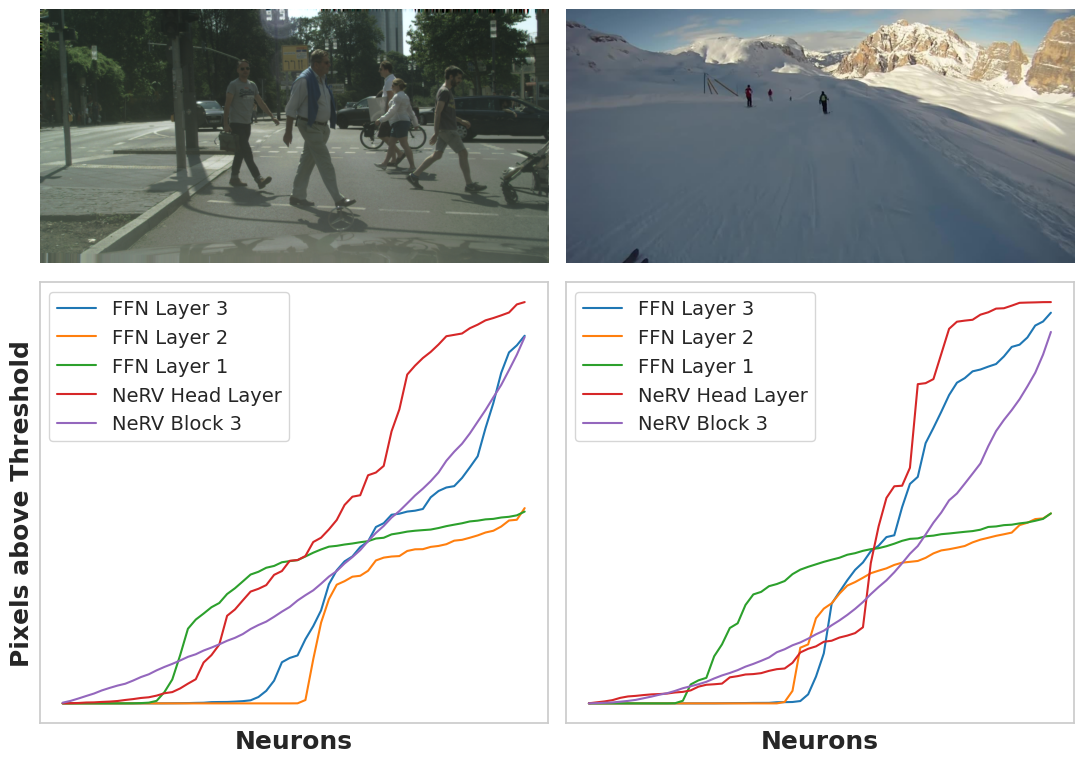

In [45]:
# Different layout
vidnames = list(nerv_per_vid_num_pixels_with_meaningful_contrib.keys())
# Remove the vids we don't want
vidnames.remove("0005")
vidnames.remove("26_cblDl5vCZnw")

fig, axs = plt.subplots(2, len(vidnames), figsize=(11, 8), tight_layout=True, gridspec_kw={'width_ratios': [1, 1], 'height_ratios':[1,1.5]})
titles_fontsize = 18


selected_thresh = 0.01

for vid_idx, vidname in enumerate(vidnames):

    img = read_image(rgb_img_paths[vidname])
    if vidname in vipseg_vids:
        img = transforms.CenterCrop((640, 1280))(img)
                    
    axs[0][vid_idx].imshow(img.permute(1,2,0).numpy())
    

    # For each sorted contrib vector, sample equally spaced points to get 60 from each
    # Sample 60 equally spaced points from each tensor
    num_samples = 60
    
    nerv_head = nerv_per_vid_num_pixels_with_meaningful_contrib[vidname]["head"]
    nerv_blk_3 = nerv_per_vid_num_pixels_with_meaningful_contrib[vidname]["blk_3"]
    mlp_layer_1 = mlp_per_vid_num_pixels_with_meaningful_contrib[vidname]["layer_1"]
    mlp_layer_2 = mlp_per_vid_num_pixels_with_meaningful_contrib[vidname]["layer_2"]
    mlp_layer_3 = mlp_per_vid_num_pixels_with_meaningful_contrib[vidname]["layer_3"]
       
    # Resample each tensor to the common length using linear interpolation
    nerv_head = F.interpolate(nerv_head.float().unsqueeze(0).unsqueeze(0), size=num_samples, mode='linear', align_corners=False).squeeze(0).squeeze(0)        
    nerv_blk_3 = F.interpolate(nerv_blk_3.float().unsqueeze(0).unsqueeze(0), size=num_samples, mode='linear', align_corners=False).squeeze(0).squeeze(0)        
    mlp_layer_1 = F.interpolate(mlp_layer_1.float().unsqueeze(0).unsqueeze(0), size=num_samples, mode='linear', align_corners=False).squeeze(0).squeeze(0)        
    mlp_layer_2 = F.interpolate(mlp_layer_2.float().unsqueeze(0).unsqueeze(0), size=num_samples, mode='linear', align_corners=False).squeeze(0).squeeze(0)        
    mlp_layer_3 = F.interpolate(mlp_layer_3.float().unsqueeze(0).unsqueeze(0), size=num_samples, mode='linear', align_corners=False).squeeze(0).squeeze(0)
    
    axs[1][vid_idx].plot(mlp_layer_3, label='FFN Layer 3', color='tab:blue')
    axs[1][vid_idx].plot(mlp_layer_2, label='FFN Layer 2', color='tab:orange')
    axs[1][vid_idx].plot(mlp_layer_1, label='FFN Layer 1', color='tab:green')
    
    axs[1][vid_idx].plot(nerv_head, label='NeRV Head Layer', color='tab:red')
    axs[1][vid_idx].plot(nerv_blk_3, label='NeRV Block 3', color='tab:purple')
    
    axs[1][vid_idx].legend(ncols=1, fontsize=14,  loc='upper left')

    
    axs[1][vid_idx].set_xlabel("Neurons", fontsize=titles_fontsize, fontweight='bold')
        
    axs[0][vid_idx].axis('off')
    
    axs[1][0].set_ylabel("Pixels above Threshold", fontsize=titles_fontsize, fontweight='bold')
    
    for vid_idx in range(len(vidnames)):
        axs[1][vid_idx].set_yticks([])
        axs[1][vid_idx].set_yticklabels([])
        axs[1][vid_idx].set_xticks([])
        axs[1][vid_idx].set_xticklabels([])

# Save figure

In [53]:
fig.savefig('outputs/B/4.2-pixels_per_neuron.pdf', bbox_inches="tight", pad_inches=0.05)